In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

In [2]:
# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / "retail_forecasting_70000.xlsx"

MODEL_FILE = BASE_DIR / "xgboost_model.pkl"
PIPELINE_FILE = BASE_DIR / "pipeline.pkl"
COLUMNS_FILE = BASE_DIR / "training_columns.pkl"
META_FILE = BASE_DIR / "model_metadata.json"

PLOT_DIR = BASE_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")

In [3]:
# ============================================================
# HELPERS
# ============================================================
def evaluate(y_true, y_pred, label=""):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f"{label} -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [4]:
# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel(DATA_FILE)
df.columns = df.columns.str.strip()

required_cols = [
    "Date", "StoreID", "Category", "Revenue",
    "UnitsSold", "UnitPrice", "DiscountApplied", "HolidayFlag"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"])

print("Initial shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Initial shape: (70000, 10)

Columns:
['TransactionID', 'Date', 'StoreID', 'ProductID', 'Category', 'UnitPrice', 'UnitsSold', 'Revenue', 'DiscountApplied', 'HolidayFlag']

Missing values:
TransactionID      0
Date               0
StoreID            0
ProductID          0
Category           0
UnitPrice          0
UnitsSold          0
Revenue            0
DiscountApplied    0
HolidayFlag        0
dtype: int64


No missing values found in the dataset.


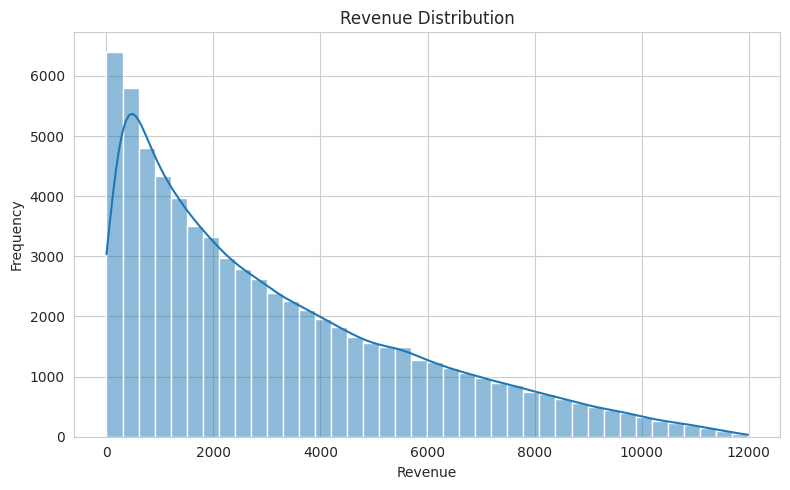

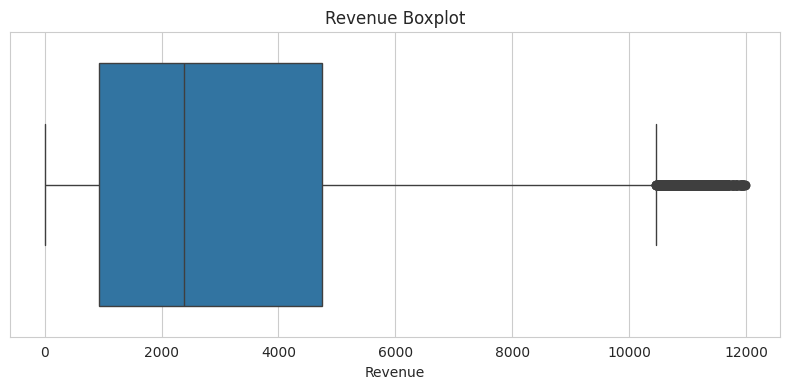

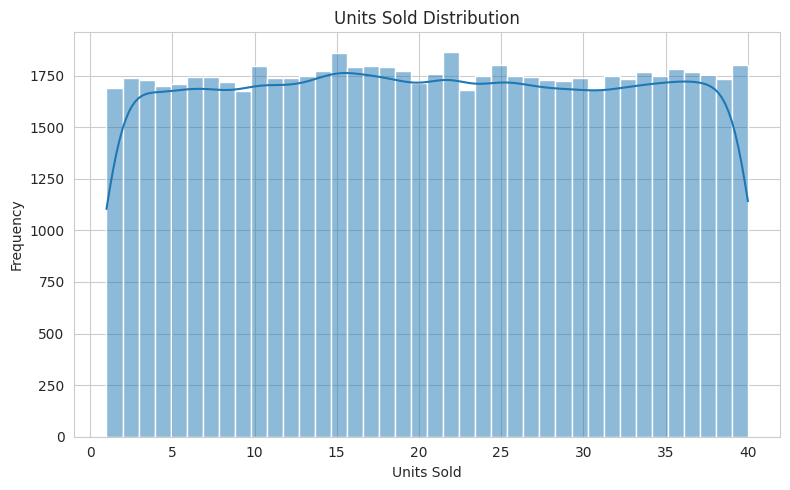

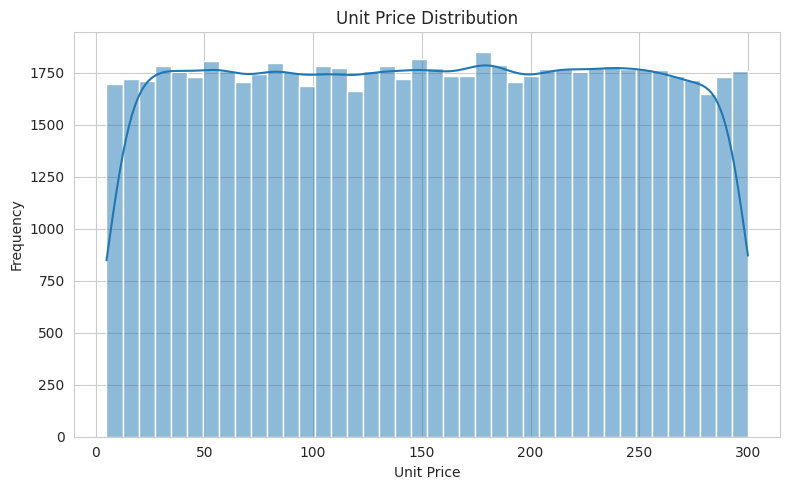

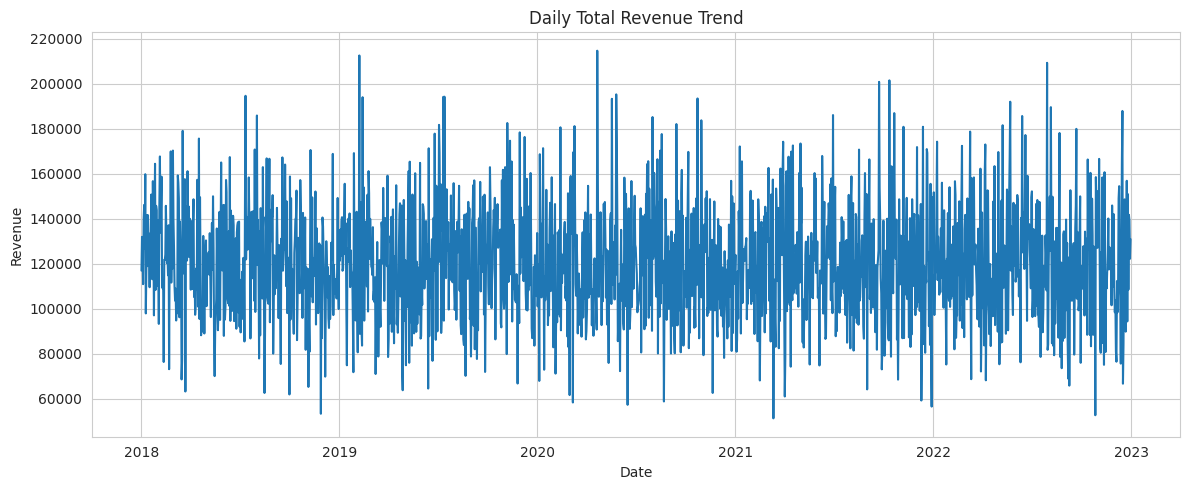

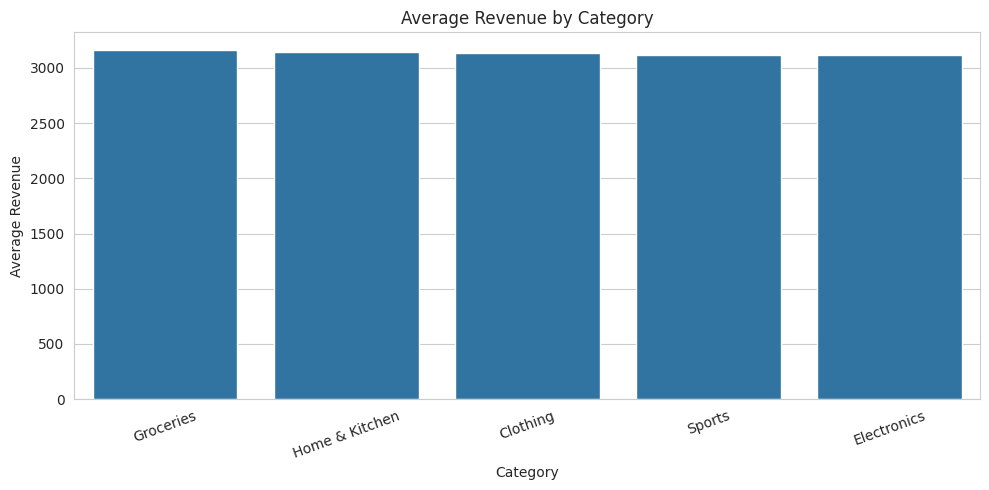

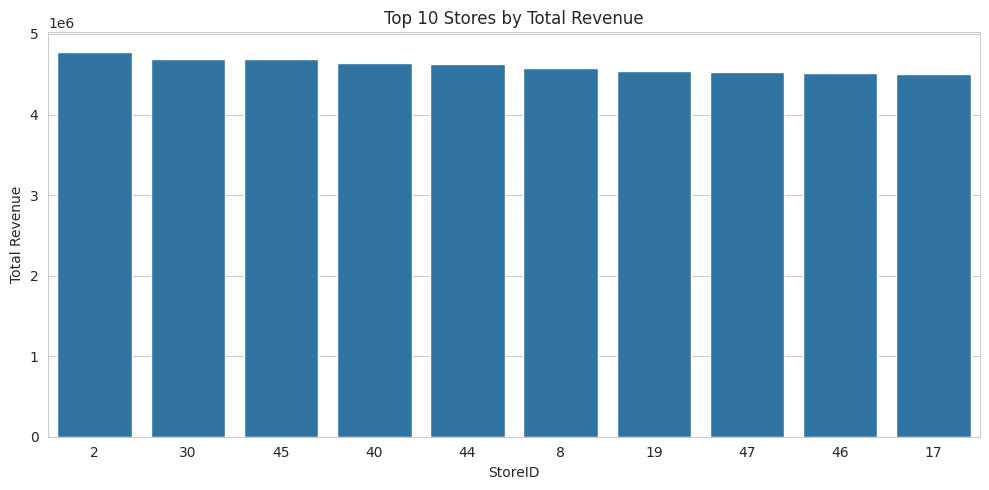

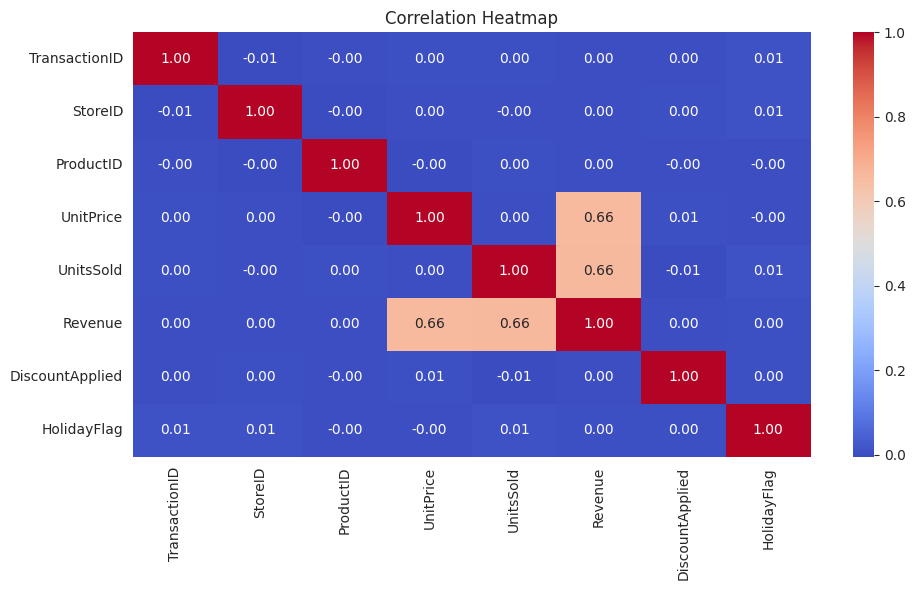

In [6]:
# ============================================================
# 2. DATA VISUALIZATION - RAW DATA
# ============================================================

# 2.1 Missing values
plt.figure(figsize=(10, 5))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if not missing_counts.empty:
    missing_counts.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    save_plot("01_missing_values.png")
else:
    print("No missing values found in the dataset.")
    plt.close() # Close the empty figure

# 2.2 Revenue distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Revenue"], kde=True, bins=40)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
save_plot("02_revenue_distribution.png")

# 2.3 Revenue boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Boxplot")
save_plot("03_revenue_boxplot.png")

# 2.4 Units sold distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["UnitsSold"], kde=True, bins=40)
plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
save_plot("04_units_sold_distribution.png")

# 2.5 Unit price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["UnitPrice"], kde=True, bins=40)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
save_plot("05_unit_price_distribution.png")

# 2.6 Daily overall revenue trend
daily_revenue_raw = df.groupby("Date", as_index=False)["Revenue"].sum()
plt.figure(figsize=(12, 5))
plt.plot(daily_revenue_raw["Date"], daily_revenue_raw["Revenue"])
plt.title("Daily Total Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
save_plot("06_daily_total_revenue_trend.png")

# 2.7 Category-wise average revenue
plt.figure(figsize=(10, 5))
category_avg = df.groupby("Category")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=category_avg.index, y=category_avg.values)
plt.title("Average Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Average Revenue")
plt.xticks(rotation=20)
save_plot("07_category_avg_revenue.png")

# 2.8 Top 10 stores by total revenue
plt.figure(figsize=(10, 5))
top_stores = df.groupby("StoreID")["Revenue"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index.astype(str), y=top_stores.values)
plt.title("Top 10 Stores by Total Revenue")
plt.xlabel("StoreID")
plt.ylabel("Total Revenue")
save_plot("08_top_stores_revenue.png")

# 2.9 Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
save_plot("09_correlation_heatmap.png")

In [7]:
# ============================================================
# 3. BASIC CLEANING
# ============================================================
df = df.dropna(subset=required_cols).copy()
df = df[df["Revenue"] >= 0]
df = df[df["UnitsSold"] >= 0]
df = df[df["UnitPrice"] > 0]
df = df[(df["DiscountApplied"] >= 0) & (df["DiscountApplied"] <= 100)]
df["HolidayFlag"] = df["HolidayFlag"].clip(0, 1).astype(int)

print("\nCleaned shape:", df.shape)


Cleaned shape: (70000, 10)


Daily shape: (64927, 8)


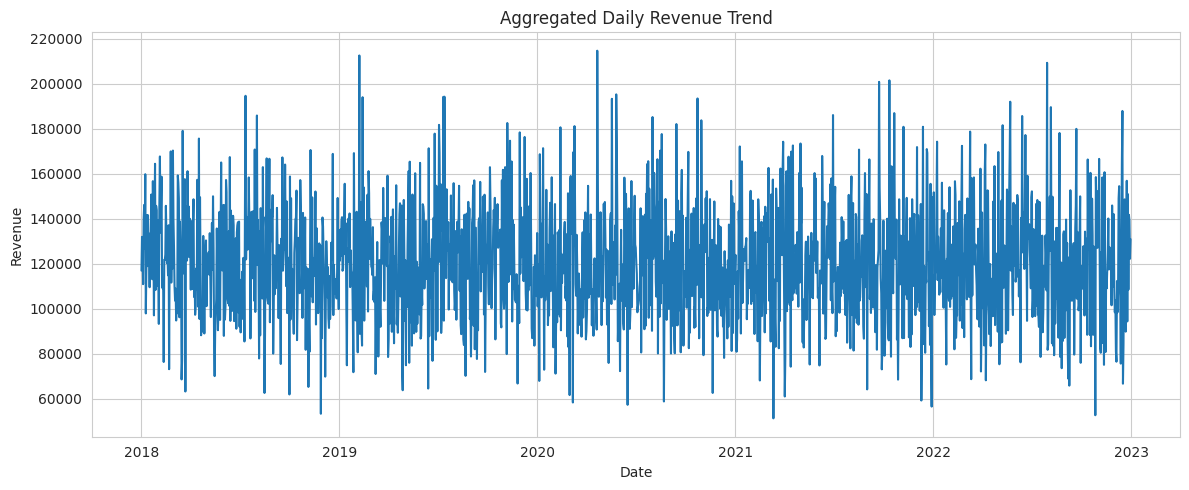

In [8]:
# ============================================================
# 4. AGGREGATE TO DAILY LEVEL PER STORE + CATEGORY
# ============================================================
daily_df = df.groupby(["Date", "StoreID", "Category"], as_index=False).agg({
    "Revenue": "sum",
    "UnitsSold": "sum",
    "UnitPrice": "mean",
    "DiscountApplied": "mean",
    "HolidayFlag": "max"
})

daily_df["StoreID"] = daily_df["StoreID"].astype(str)
daily_df["Category"] = daily_df["Category"].astype(str)

daily_df = daily_df.sort_values(["StoreID", "Category", "Date"]).reset_index(drop=True)
print("Daily shape:", daily_df.shape)

# Aggregated daily revenue trend
agg_daily_total = daily_df.groupby("Date", as_index=False)["Revenue"].sum()
plt.figure(figsize=(12, 5))
plt.plot(agg_daily_total["Date"], agg_daily_total["Revenue"])
plt.title("Aggregated Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
save_plot("10_aggregated_daily_revenue_trend.png")

In [9]:
# 5. FEATURE ENGINEERING
# ============================================================
daily_df["year"] = daily_df["Date"].dt.year
daily_df["month"] = daily_df["Date"].dt.month
daily_df["day"] = daily_df["Date"].dt.day
daily_df["day_of_week"] = daily_df["Date"].dt.dayofweek
daily_df["week_of_year"] = daily_df["Date"].dt.isocalendar().week.astype(int)

group_keys = ["StoreID", "Category"]
grouped_rev = daily_df.groupby(group_keys)["Revenue"]

daily_df["lag_1"] = grouped_rev.shift(1)
daily_df["lag_7"] = grouped_rev.shift(7)
daily_df["lag_30"] = grouped_rev.shift(30)

daily_df["rolling_mean_7"] = (
    daily_df.groupby(group_keys)["Revenue"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

daily_df["rolling_mean_30"] = (
    daily_df.groupby(group_keys)["Revenue"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

daily_df = daily_df.dropna().reset_index(drop=True)

# Full one-hot encoding
daily_df = pd.get_dummies(
    daily_df,
    columns=["StoreID", "Category"],
    drop_first=False
)

Train rows: 45325 | Test rows: 12102
Train date range: 2018-05-12 00:00:00 to 2022-01-28 00:00:00
Test date range: 2022-01-29 00:00:00 to 2022-12-31 00:00:00


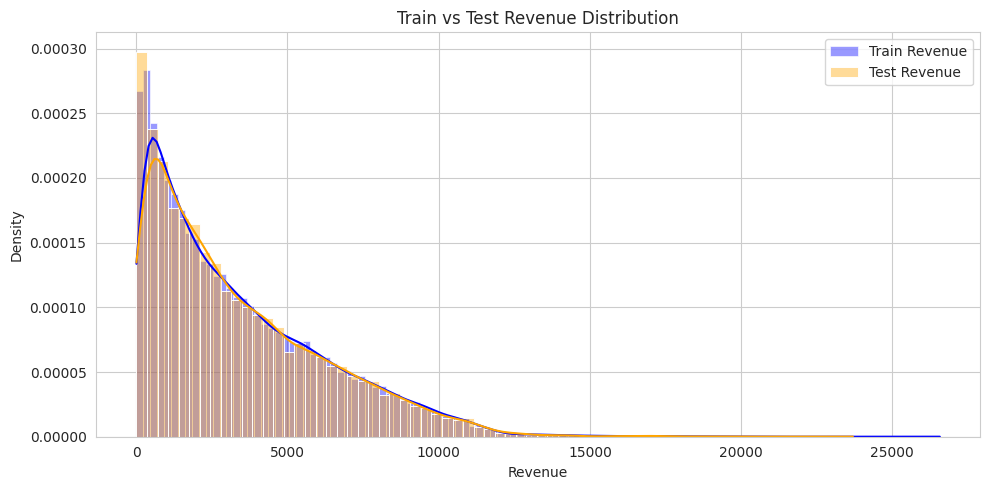

In [10]:
# ============================================================
# 6. DATE-BASED TRAIN / TEST SPLIT
# ============================================================
unique_dates = np.array(sorted(daily_df["Date"].unique()))
cutoff_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[cutoff_idx]

train_df = daily_df[daily_df["Date"] < cutoff_date].copy()
test_df = daily_df[daily_df["Date"] >= cutoff_date].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Train/test split failed. Check dataset size and date distribution.")

X_train = train_df.drop(columns=["Date", "Revenue"])
y_train = train_df["Revenue"]

X_test = test_df.drop(columns=["Date", "Revenue"])
y_test = test_df["Revenue"]

print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test date range:", test_df["Date"].min(), "to", test_df["Date"].max())

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train vs test target distribution
plt.figure(figsize=(10, 5))
sns.histplot(y_train, color="blue", label="Train Revenue", kde=True, stat="density", alpha=0.4)
sns.histplot(y_test, color="orange", label="Test Revenue", kde=True, stat="density", alpha=0.4)
plt.legend()
plt.title("Train vs Test Revenue Distribution")
save_plot("11_train_test_revenue_distribution.png")

In [11]:
# ============================================================
# 7. SCALING PIPELINE
# ============================================================
pipeline = Pipeline([
    ("scaler", StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

Linear Regression -> RMSE: 1075.58 | MAE: 788.29 | R2: 0.8620
Random Forest -> RMSE: 285.45 | MAE: 75.21 | R2: 0.9903
XGBoost Baseline -> RMSE: 276.62 | MAE: 78.18 | R2: 0.9909


<Figure size 1000x500 with 0 Axes>

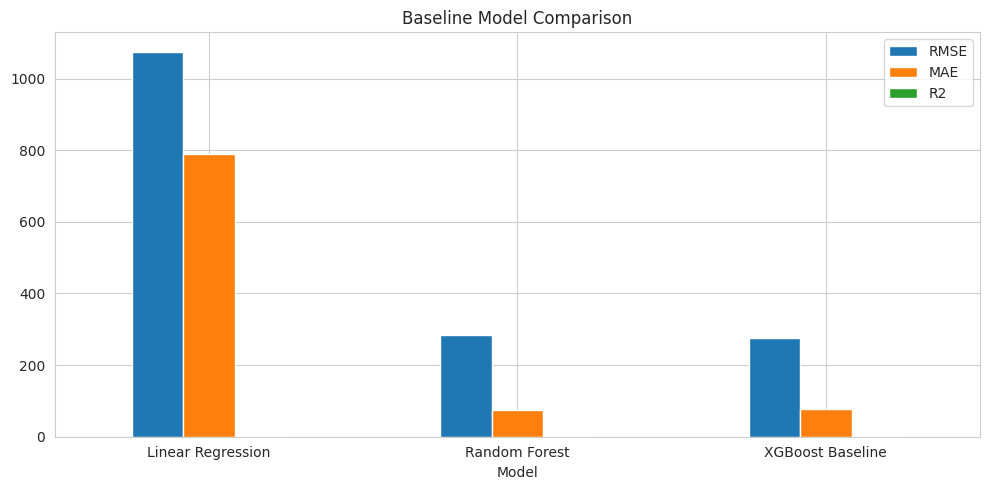

In [12]:
# ============================================================
# 8. BASELINE MODELS
# ============================================================
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
xgb = XGBRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

lr_metrics = evaluate(y_test, lr.predict(X_test_scaled), "Linear Regression")
rf_metrics = evaluate(y_test, rf.predict(X_test_scaled), "Random Forest")
xgb_metrics = evaluate(y_test, xgb.predict(X_test_scaled), "XGBoost Baseline")

# Model comparison chart
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost Baseline"],
    "RMSE": [
        lr_metrics["rmse"],
        rf_metrics["rmse"],
        xgb_metrics["rmse"],
    ],
    "MAE": [
        lr_metrics["mae"],
        rf_metrics["mae"],
        xgb_metrics["mae"],
    ],
    "R2": [
        lr_metrics["r2"],
        rf_metrics["r2"],
        xgb_metrics["r2"],
    ],
})

plt.figure(figsize=(10, 5))
comparison_plot = comparison_df.set_index("Model")[["RMSE", "MAE", "R2"]]
comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Model Comparison")
plt.xticks(rotation=0)
save_plot("12_baseline_model_comparison.png")

In [13]:
# ============================================================
# 9. HYPERPARAMETER TUNING
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
tuned_pred = best_model.predict(X_test_scaled)
tuned_metrics = evaluate(y_test, tuned_pred, "Tuned XGBoost")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tuned XGBoost -> RMSE: 272.48 | MAE: 81.67 | R2: 0.9911


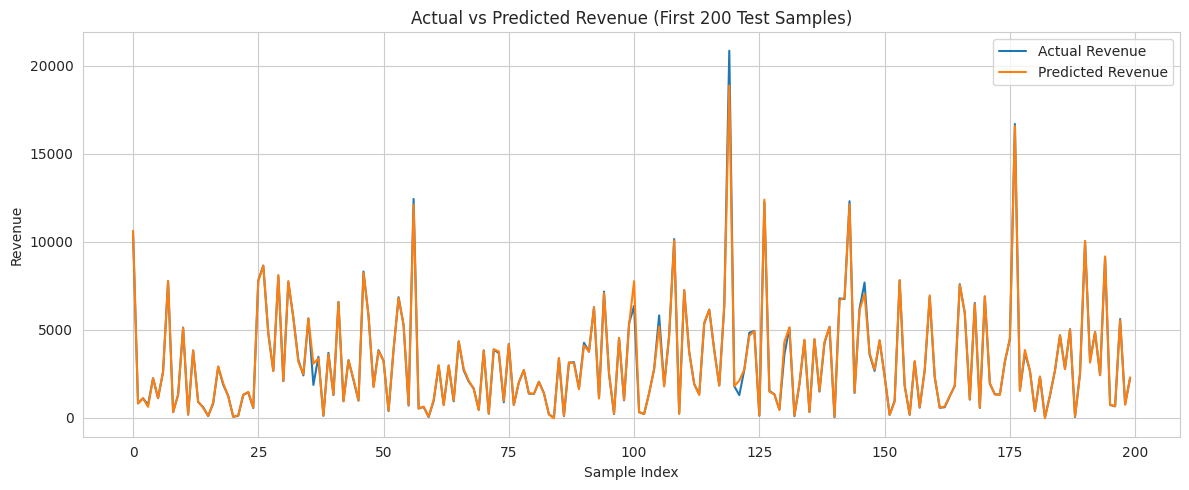

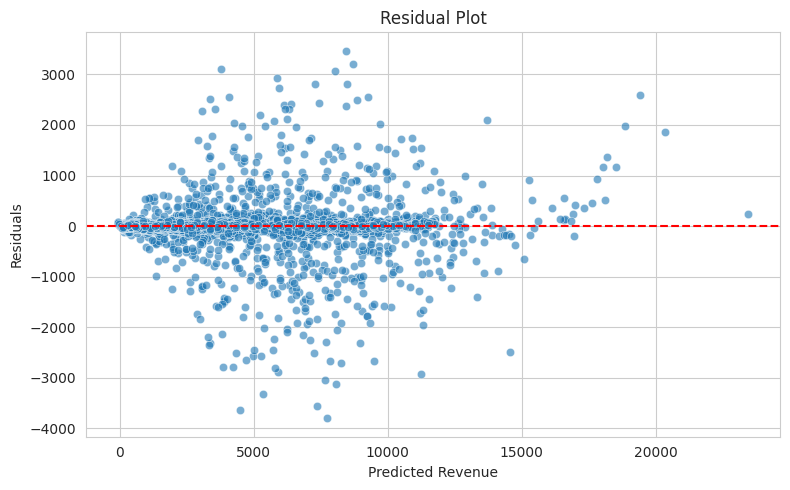

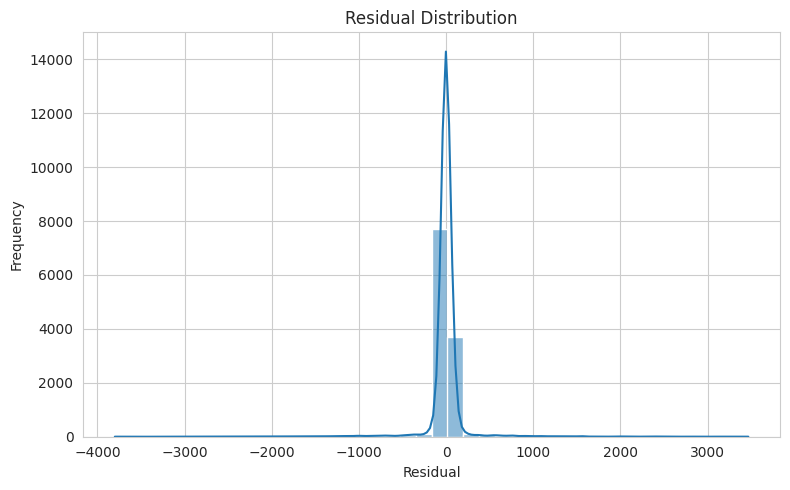

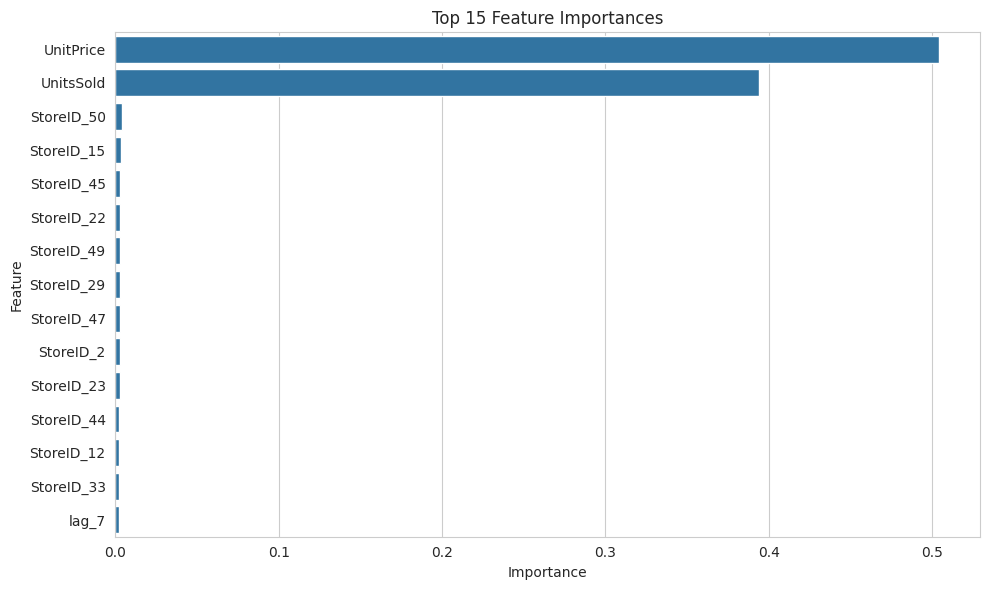

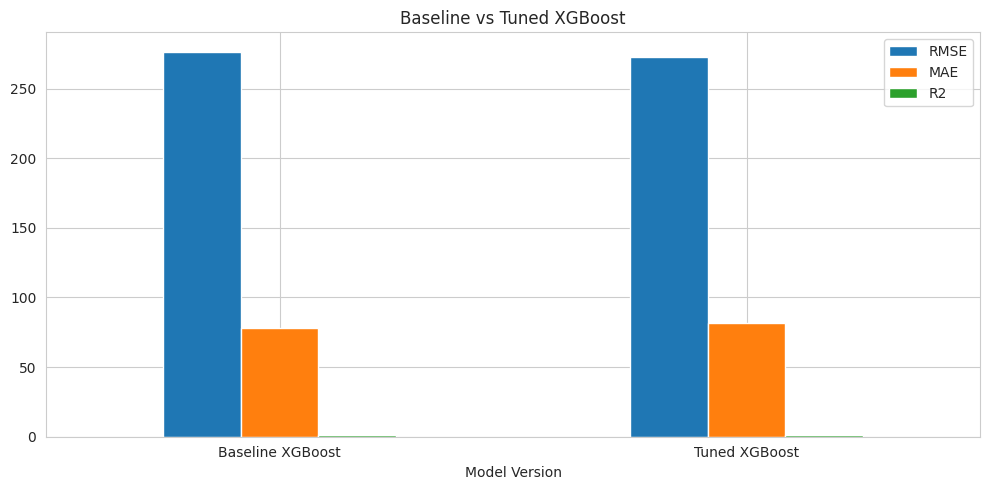

In [14]:
# ============================================================
# 10. FINAL VISUALIZATIONS
# ============================================================

# 10.1 Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Actual Revenue")
plt.plot(tuned_pred[:200], label="Predicted Revenue")
plt.title("Actual vs Predicted Revenue (First 200 Test Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Revenue")
plt.legend()
save_plot("13_actual_vs_predicted.png")

# 10.2 Residual plot
residuals = y_test.values - tuned_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=tuned_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--", color="red")
plt.title("Residual Plot")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
save_plot("14_residual_plot.png")

# 10.3 Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
save_plot("15_residual_distribution.png")

# 10.4 Feature importance
feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
save_plot("16_feature_importance.png")

# 10.5 Baseline vs tuned comparison
final_compare = pd.DataFrame({
    "Model Version": ["Baseline XGBoost", "Tuned XGBoost"],
    "RMSE": [xgb_metrics["rmse"], tuned_metrics["rmse"]],
    "MAE": [xgb_metrics["mae"], tuned_metrics["mae"]],
    "R2": [xgb_metrics["r2"], tuned_metrics["r2"]],
})

final_compare.set_index("Model Version")[["RMSE", "MAE", "R2"]].plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs Tuned XGBoost")
plt.xticks(rotation=0)
save_plot("17_baseline_vs_tuned.png")

In [15]:
# ============================================================
# 11. SAVE ARTIFACTS
# ============================================================
joblib.dump(best_model, MODEL_FILE)
joblib.dump(list(X_train.columns), COLUMNS_FILE)
joblib.dump(pipeline, PIPELINE_FILE)

metadata = {
    "model_name": "Tuned XGBoost Revenue Forecast Model",
    "target": "Revenue",
    "best_params": grid_search.best_params_,
    "baseline_metrics": {
        "linear_regression": lr_metrics,
        "random_forest": rf_metrics,
        "xgboost_baseline": xgb_metrics
    },
    "final_metrics": tuned_metrics,
    "feature_count": len(X_train.columns),
    "training_columns": list(X_train.columns),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_start": str(train_df["Date"].min().date()),
    "train_end": str(train_df["Date"].max().date()),
    "test_start": str(test_df["Date"].min().date()),
    "test_end": str(test_df["Date"].max().date())
}

with open(META_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("-", MODEL_FILE.name)
print("-", COLUMNS_FILE.name)
print("-", PIPELINE_FILE.name)
print("-", META_FILE.name)
print("-", "plots/ (all visualization images)")

Saved:
- xgboost_model.pkl
- training_columns.pkl
- pipeline.pkl
- model_metadata.json
- plots/ (all visualization images)
